In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
# Loading and exploring the databset 
# Load the dataset
url = "../data/Mall_Customers.csv"
try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    # Alternative source if the local file is not found
    url_alt = "https://raw.githubusercontent.com/plotly/datasets/master/mall_customers.csv"
    df = pd.read_csv(url_alt)
    print("Dataset loaded using alternative source!")

print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print(f"\nMissing Values: {df.isnull().sum().sum()}")

Dataset loaded successfully!

Dataset Shape: 200 rows, 5 columns

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memo

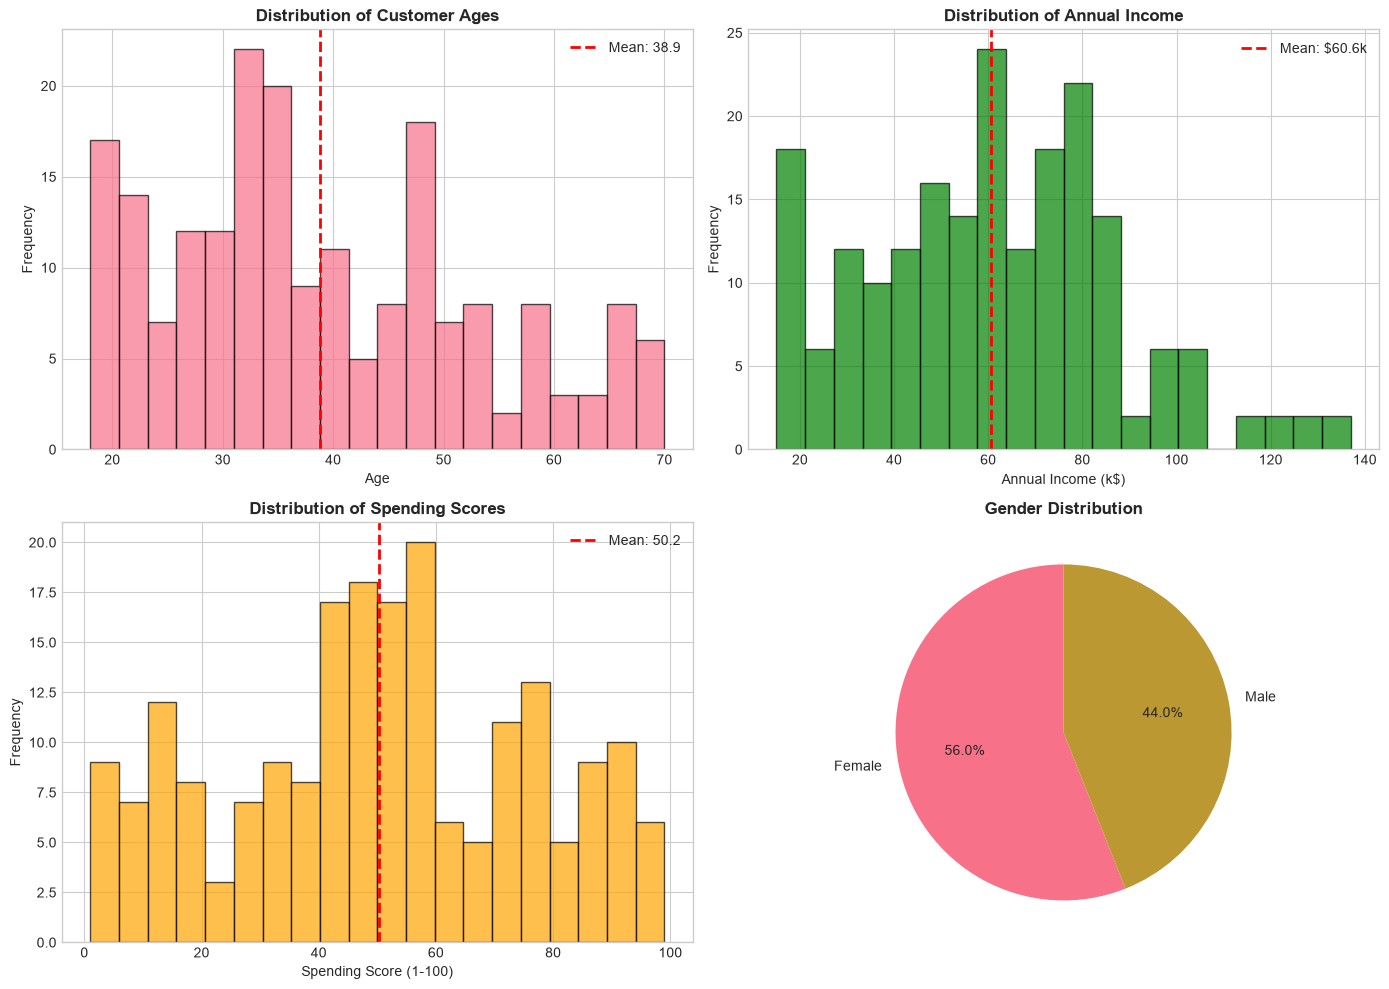

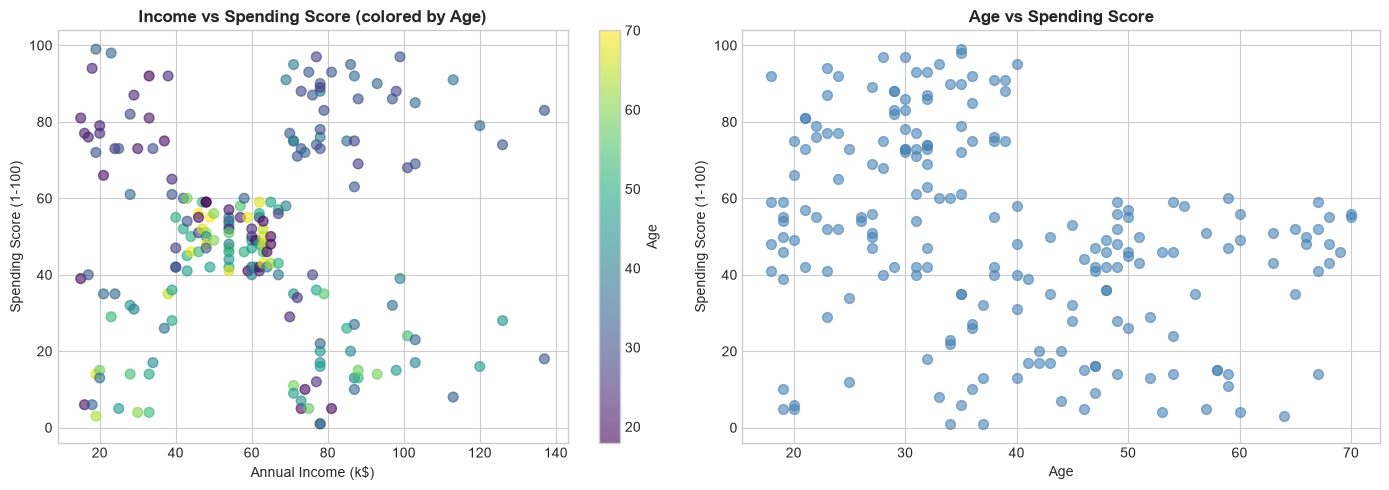

In [3]:
# Distributions of Age, Income, and Spending Score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Age'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['Age'].mean(), color='red', linestyle='dashed',
                   linewidth=2, label=f"Mean: {df['Age'].mean():.1f}")
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Customer Ages', fontweight='bold')
axes[0, 0].legend()

axes[0, 1].hist(df['Annual Income (k$)'], bins=20, edgecolor='black',
                   alpha=0.7, color='green')
axes[0, 1].axvline(df['Annual Income (k$)'].mean(), color='red',
                   linestyle='dashed', linewidth=2,
                   label=f"Mean: ${df['Annual Income (k$)'].mean():.1f}k")
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Annual Income', fontweight='bold')
axes[0, 1].legend()

axes[1, 0].hist(df['Spending Score (1-100)'], bins=20, edgecolor='black',
                   alpha=0.7, color='orange')
axes[1, 0].axvline(df['Spending Score (1-100)'].mean(), color='red',
                   linestyle='dashed', linewidth=2,
                   label=f"Mean: {df['Spending Score (1-100)'].mean():.1f}")
axes[1, 0].set_xlabel('Spending Score (1-100)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Spending Scores', fontweight='bold')
axes[1, 0].legend()

gender_counts = df['Gender'].value_counts()
axes[1, 1].pie(gender_counts.values, labels=gender_counts.index,
               autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Gender Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()


# Relationships between features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                         c=df['Age'], cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Income vs Spending Score (colored by Age)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Age')

axes[1].scatter(df['Age'], df['Spending Score (1-100)'], alpha=0.6,
                c='steelblue', s=50)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('Age vs Spending Score', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
# Select features for clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

print(f"Selected features: {features}")
print(f"Feature matrix shape: {X.shape}")

# Standardize the features (crucial for k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features standardized (mean=0, std=1)")

print("\nSample of scaled features (first 10 rows):")
print(pd.DataFrame(X_scaled[:10], columns=['Scaled Income', 'Scaled Spending']))

Selected features: ['Annual Income (k$)', 'Spending Score (1-100)']
Feature matrix shape: (200, 2)
Features standardized (mean=0, std=1)

Sample of scaled features (first 10 rows):
   Scaled Income  Scaled Spending
0      -1.738999        -0.434801
1      -1.738999         1.195704
2      -1.700830        -1.715913
3      -1.700830         1.040418
4      -1.662660        -0.395980
5      -1.662660         1.001596
6      -1.624491        -1.715913
7      -1.624491         1.700384
8      -1.586321        -1.832378
9      -1.586321         0.846310


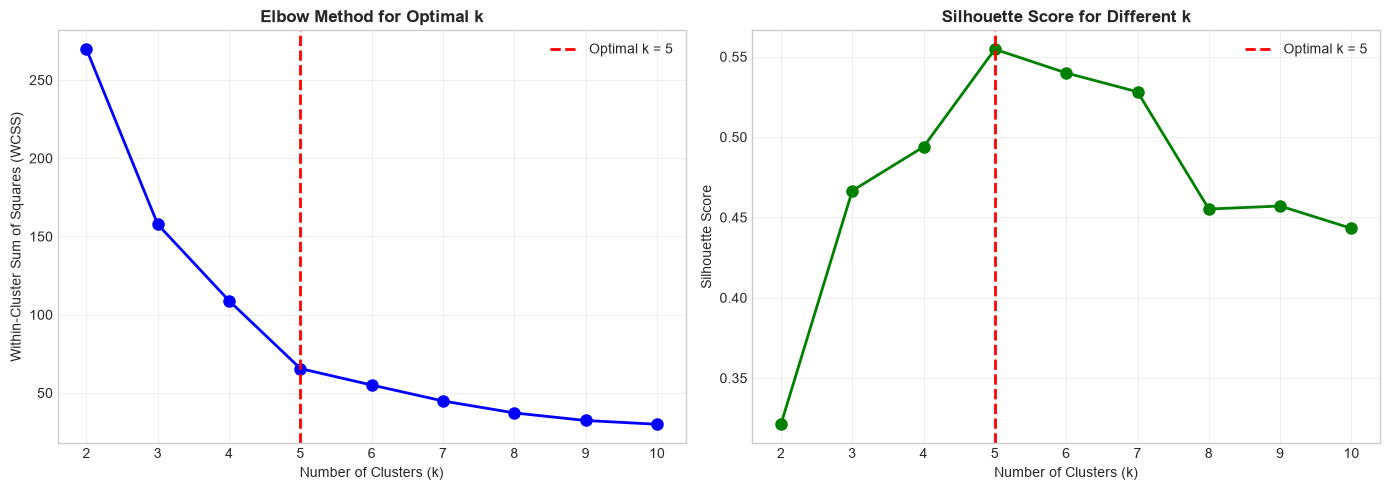


Optimal number of clusters determined: k = 5
(Based on elbow point at k=5 and high silhouette score)


In [5]:
# Calculate WCSS and silhouette score for a range of k values
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal k = 5')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0].set_title('Elbow Method for Optimal k', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal k = 5')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('optimal_k_determination.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = 5
print(f"\nOptimal number of clusters determined: k = {optimal_k}")
print("(Based on elbow point at k=5 and high silhouette score)")

In [8]:
# Apply K-Means with the optimal k
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the original dataframe
df['Cluster'] = y_kmeans

# Get cluster centers in the original (unscaled) units
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

print("K-Means clustering completed!")
print("\nCluster Distribution:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for i in range(optimal_k):
    pct = cluster_counts[i] / len(df) * 100
    print(f"  Cluster {i}: {cluster_counts[i]} customers ({pct:.1f}%)")

K-Means clustering completed!

Cluster Distribution:
  Cluster 0: 81 customers (40.5%)
  Cluster 1: 39 customers (19.5%)
  Cluster 2: 22 customers (11.0%)
  Cluster 3: 35 customers (17.5%)
  Cluster 4: 23 customers (11.5%)


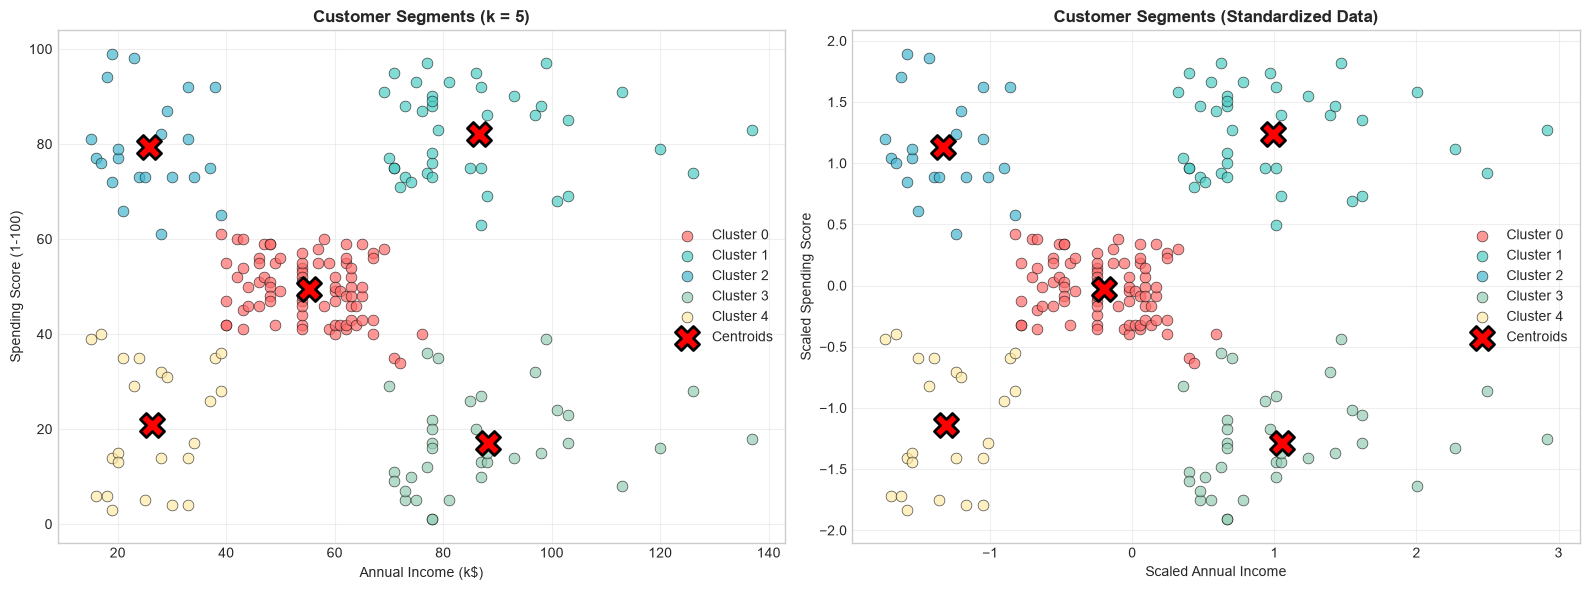

In [9]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clusters in original scale
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    axes[0].scatter(cluster_data['Annual Income (k$)'],
                    cluster_data['Spending Score (1-100)'],
                    c=colors[i], label=f'Cluster {i}', alpha=0.7, s=60,
                    edgecolors='black', linewidth=0.5)

axes[0].scatter(centers_original[:, 0], centers_original[:, 1],
                c='red', marker='X', s=300, edgecolors='black',
                linewidth=2, label='Centroids')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title(f'Customer Segments (k = {optimal_k})', fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

# Clusters in standardized scale
for i in range(optimal_k):
    cluster_data_scaled = X_scaled[y_kmeans == i]
    axes[1].scatter(cluster_data_scaled[:, 0], cluster_data_scaled[:, 1],
                    c=colors[i], label=f'Cluster {i}', alpha=0.7, s=60,
                    edgecolors='black', linewidth=0.5)

axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=300, edgecolors='black',
                linewidth=2, label='Centroids')
axes[1].set_xlabel('Scaled Annual Income')
axes[1].set_ylabel('Scaled Spending Score')
axes[1].set_title('Customer Segments (Standardized Data)', fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

CLUSTERING PERFORMANCE METRICS:
  Silhouette Score: 0.5547
  (Range: -1 to 1, higher is better; >0.5 indicates good clustering)

  Calinski-Harabasz Index: 248.65
  (Higher values indicate better-defined clusters)

  Davies-Bouldin Index: 0.5722
  (Lower values indicate better separation; 0 is perfect)

Excellent silhouette score - clusters are well-separated


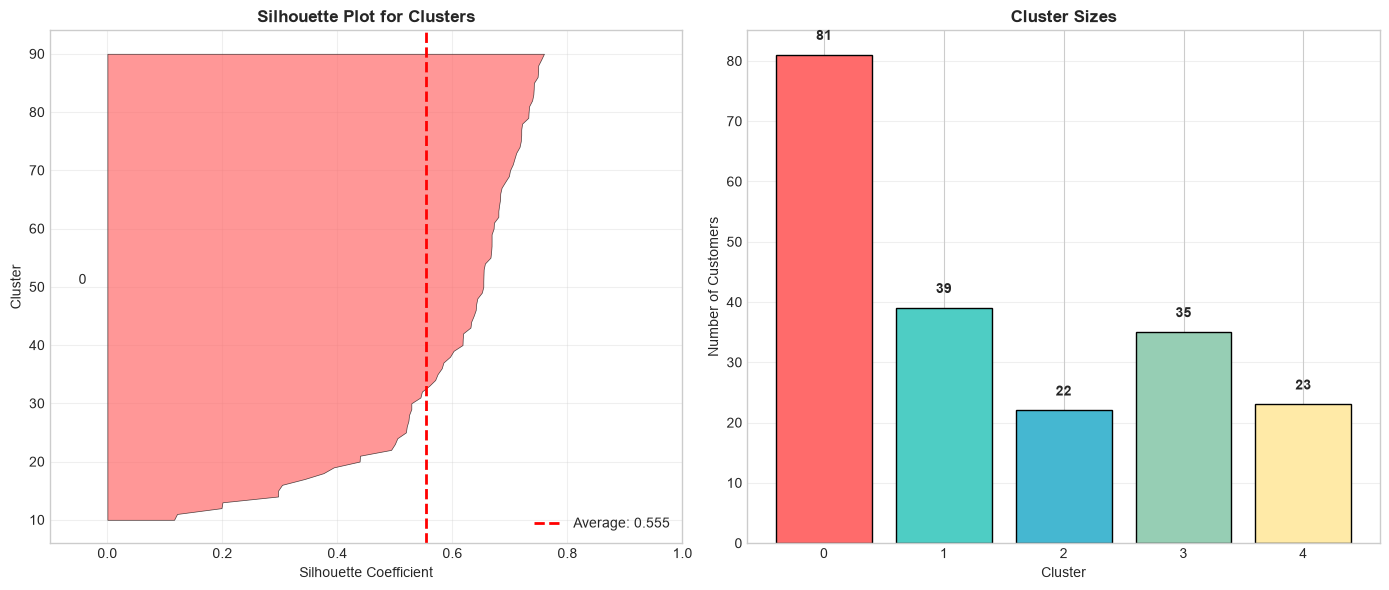

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:
# Compute clustering quality metrics
sil_score = silhouette_score(X_scaled, y_kmeans)
calinski_score = calinski_harabasz_score(X_scaled, y_kmeans)
davies_bouldin = davies_bouldin_score(X_scaled, y_kmeans)

print("CLUSTERING PERFORMANCE METRICS:")
print(f"  Silhouette Score: {sil_score:.4f}")
print("  (Range: -1 to 1, higher is better; >0.5 indicates good clustering)")
print(f"\n  Calinski-Harabasz Index: {calinski_score:.2f}")
print("  (Higher values indicate better-defined clusters)")
print(f"\n  Davies-Bouldin Index: {davies_bouldin:.4f}")
print("  (Lower values indicate better separation; 0 is perfect)")

if sil_score > 0.5:
    print("\nExcellent silhouette score - clusters are well-separated")
elif sil_score > 0.3:
    print("\nGood silhouette score - reasonable cluster structure")
else:
    print("\nLow silhouette score - clusters may overlap significantly")

# Per-sample silhouette plot
silhouette_vals = silhouette_samples(X_scaled, y_kmeans)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

y_lower = 10
for i in range(optimal_k):
    ith_cluster_silhouette = silhouette_vals[y_kmeans == i]
    ith_cluster_silhouette.sort()
    size_cluster = ith_cluster_silhouette.shape[0]
    y_upper = y_lower + size_cluster
    
    ax[0].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette,
                        facecolor=colors[i], alpha=0.7, edgecolor='black',
                        linewidth=0.5)
    ax[0].text(-0.05, y_lower + size_cluster / 2, str(i))
    y_lower = y_upper + 10

    ax[0].axvline(x=sil_score, color='red', linestyle='--', linewidth=2,
              label=f'Average: {sil_score:.3f}')
    ax[0].set_xlabel('Silhouette Coefficient')
    ax[0].set_ylabel('Cluster')
    ax[0].set_title('Silhouette Plot for Clusters', fontweight='bold')
    ax[0].set_xlim([-0.1, 1])
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    cluster_sizes = df['Cluster'].value_counts().sort_index()
    bars = ax[1].bar(range(optimal_k), cluster_sizes.values, color=colors, edgecolor='black')
    ax[1].set_xlabel('Cluster')
    ax[1].set_ylabel('Number of Customers')
    ax[1].set_title('Cluster Sizes', fontweight='bold')
    ax[1].set_xticks(range(optimal_k))
    for bar, size in zip(bars, cluster_sizes.values):
        ax[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(size), ha='center', va='bottom', fontweight='bold')
    ax[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('cluster_quality_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()

In [13]:
# Cluster profiles: average Age, Income, Spending Score per cluster
print("CLUSTER PROFILES:")
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    pct = len(cluster_data) / len(df) * 100
    print(f"\nCLUSTER {i}: {len(cluster_data)} customers ({pct:.1f}%)")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f} years")
    print(f"  Average Income: ${cluster_data['Annual Income (k$)'].mean():.1f}k")
    print(f"  Average Spending Score: {cluster_data['Spending Score (1-100)'].mean():.1f}/100")

# Business interpretation based on income/spending thresholds
cluster_centers_df = pd.DataFrame(centers_original, columns=['Income', 'Spending'])
cluster_centers_df['Cluster'] = range(optimal_k)

print("\nBUSINESS INSIGHTS & CUSTOMER SEGMENTS:")
for idx, row in cluster_centers_df.iterrows():
    income, spending = row['Income'], row['Spending']
    
    if income > 70 and spending > 60:
        label = "HIGH VALUE CUSTOMERS"
        strategy = "Premium loyalty programs, exclusive offers, VIP treatment"
    elif income > 70 and spending <= 60:
        label = "TARGETABLE WEALTHY"
        strategy = "Encourage spending with premium product recommendations"
    elif income <= 70 and spending > 60:
        label = "ASPIRATIONAL SHOPPERS"
        strategy = "Installment plans, targeted discounts, bundled offers"
    elif income <= 40 and spending <= 40:
        label = "FRUGAL CUSTOMERS"
        strategy = "Value-focused marketing, essentials, budget-friendly deals"
    else:
        label = "MODERATE CUSTOMERS"
        strategy = "Cross-selling, up-selling, regular engagement campaigns"
        
    print(f"\nCluster {idx}: {label} (Income: ${income:.0f}k, Spending: {spending:.0f})")
    print(f"  Strategy: {strategy}")

CLUSTER PROFILES:

CLUSTER 0: 81 customers (40.5%)
  Average Age: 42.7 years
  Average Income: $55.3k
  Average Spending Score: 49.5/100

CLUSTER 1: 39 customers (19.5%)
  Average Age: 32.7 years
  Average Income: $86.5k
  Average Spending Score: 82.1/100

CLUSTER 2: 22 customers (11.0%)
  Average Age: 25.3 years
  Average Income: $25.7k
  Average Spending Score: 79.4/100

CLUSTER 3: 35 customers (17.5%)
  Average Age: 41.1 years
  Average Income: $88.2k
  Average Spending Score: 17.1/100

CLUSTER 4: 23 customers (11.5%)
  Average Age: 45.2 years
  Average Income: $26.3k
  Average Spending Score: 20.9/100

BUSINESS INSIGHTS & CUSTOMER SEGMENTS:

Cluster 0: MODERATE CUSTOMERS (Income: $55k, Spending: 50)
  Strategy: Cross-selling, up-selling, regular engagement campaigns

Cluster 1: HIGH VALUE CUSTOMERS (Income: $87k, Spending: 82)
  Strategy: Premium loyalty programs, exclusive offers, VIP treatment

Cluster 2: ASPIRATIONAL SHOPPERS (Income: $26k, Spending: 79)
  Strategy: Installment 